# Advanced Data Visualization & Storytelling Dashboard

## Amaç
Bu proje, analiz sonuçlarını yalnızca grafikle göstermek değil,
veriyi bir hikâye akışı içinde sunmayı hedefler.

## Neden İleri Seviye Görselleştirme?
- Yönetim ham tablo okumaz
- Çok grafik ≠ çok değer
- Net mesaj > karmaşık analiz

## Kullanılan Konular
- İleri seviye subplots
- Görsel geliştirmeler
- Annotation ve yönlendirme
- Farklı grafik türleri
- Dashboard mantığı

In [12]:
# Veri Hazırlığı

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd

np.random.seed(42)

# 1️⃣ Satış Trend
months = ['Ocak', 'Şub', 'Mart', 'Nis', 'May', 'Haz', 'Tem', 'Ağu', 'Eyl', 'Ekim', 'Kas', 'Ara']
sales_trend = [120, 135, 150, 210, 240, 235, 190, 180, 220, 250, 280, 310]

# 2️⃣ Ürün Payları
products = ['Ürün A', 'Ürün B', 'Ürün C', 'Diğer']
product_shares = [35, 45, 15, 5]

# 3️⃣ Bölge Performansı
regions = ['Marmara', 'İç Anadolu', 'Ege', 'Akdeniz']
region_perf = [95, 80, 70, 65]

# 4️⃣ Müşteri Davranışı
loyalty_score = np.random.randint(10, 100, 50)
spending_amount = loyalty_score * 1.8 + np.random.normal(0, 15, 50)

print("✅ Veri hazır.")

✅ Veri hazır.


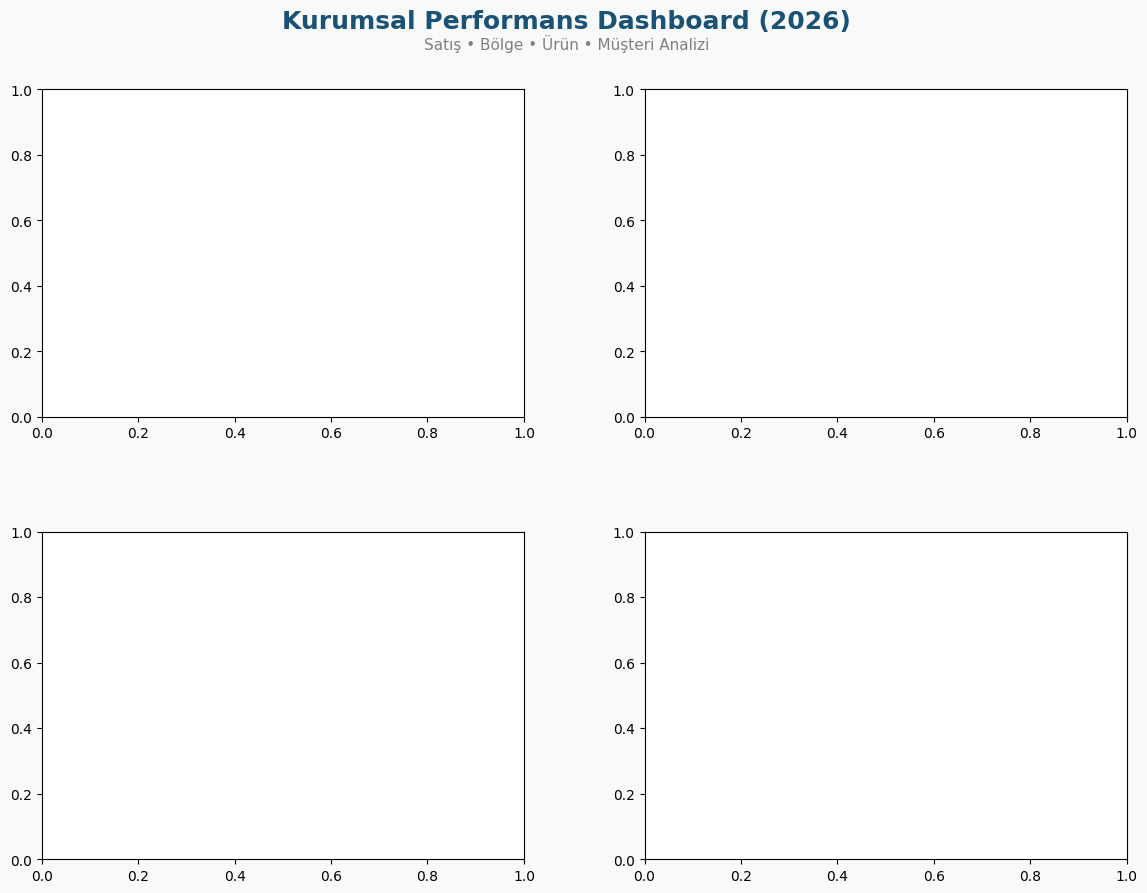

In [34]:
# 3. Subplots
PRIMARY_COLOR = '#1A5276'
SECONDARY_COLOR = '#5DADE2'
HIGHLIGHT_COLOR = '#E74C3C'
BG_COLOR = '#F8F9F9'

fig, axs = plt.subplots(2, 2, figsize=(14, 10), facecolor=BG_COLOR)

# Ana başlık
fig.suptitle(
    'Kurumsal Performans Dashboard (2026)',
    fontsize=18,
    fontweight='bold',
    color=PRIMARY_COLOR,
    y=0.96
)

# Daha sade subtitle
fig.text(
    0.5,
    0.92,
    'Satış • Bölge • Ürün • Müşteri Analizi',
    ha='center',
    fontsize=11,
    color='gray'
)

plt.subplots_adjust(hspace=0.35, wspace=0.25)

In [26]:
# 4. Grafik Yerleşimi + Annotation
# --- 1️⃣ LINE PLOT: Satış Trend ---
axs[0, 0].plot(months, sales_trend,
               color=PRIMARY_COLOR,
               linewidth=3,
               marker='o',
               markersize=7,
               label='Sales Trend')

axs[0, 0].set_title('Aylık Satış Trend Analizi',
                    fontsize=13,
                    fontweight='bold',
                    loc='left')

# Yatay grid (trend okumayı kolaylaştırır)
axs[0, 0].grid(axis='y', linestyle='--', alpha=0.4)

# En yüksek noktayı vurgula
max_idx = np.argmax(sales_trend)

axs[0, 0].annotate(
    'Rekor Satış',
    xy=(months[max_idx], sales_trend[max_idx]),
    xytext=(months[max_idx-2], sales_trend[max_idx]-40),
    arrowprops=dict(arrowstyle='->',
                    color=HIGHLIGHT_COLOR,
                    lw=2),
    fontsize=10,
    fontweight='bold',
    color=HIGHLIGHT_COLOR
)

axs[0, 0].legend()

# --- 2️⃣ BAR PLOT: Bölgesel Performans ---
bars = axs[0, 1].bar(regions,
                     region_perf,
                     color=SECONDARY_COLOR,
                     edgecolor=PRIMARY_COLOR)

axs[0, 1].set_title('Bölgesel Başarı Skorları',
                    fontsize=13,
                    fontweight='bold',
                    loc='left')

axs[0, 1].grid(axis='y', linestyle=':', alpha=0.3)

# Bar üstüne değer yaz (Text ekleme)
for bar in bars:
    height = bar.get_height()
    axs[0, 1].text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        f'{height}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Üst ve sağ çerçeveyi kaldır (temizlik)
for ax in [axs[0,0], axs[0,1]]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

In [27]:
# 5. Görsellik (İleri Seviye
# 🎨 Tutarlı Renk Paleti + Font Hiyerarşisi)

# Renk paleti
primary_color = "#1f77b4"
secondary_color = "#ff7f0e"
accent_color = "#2ca02c"
neutral_color = "#9467bd"

# Başlık hiyerarşisi
fig.suptitle("Enterprise Performance Dashboard",
             fontsize=18,
             fontweight='bold')

for ax in axs.flat:
    ax.title.set_fontsize(12)
    ax.tick_params(axis='x', rotation=30)
    ax.set_facecolor("#f9f9f9")  # hafif arka plan

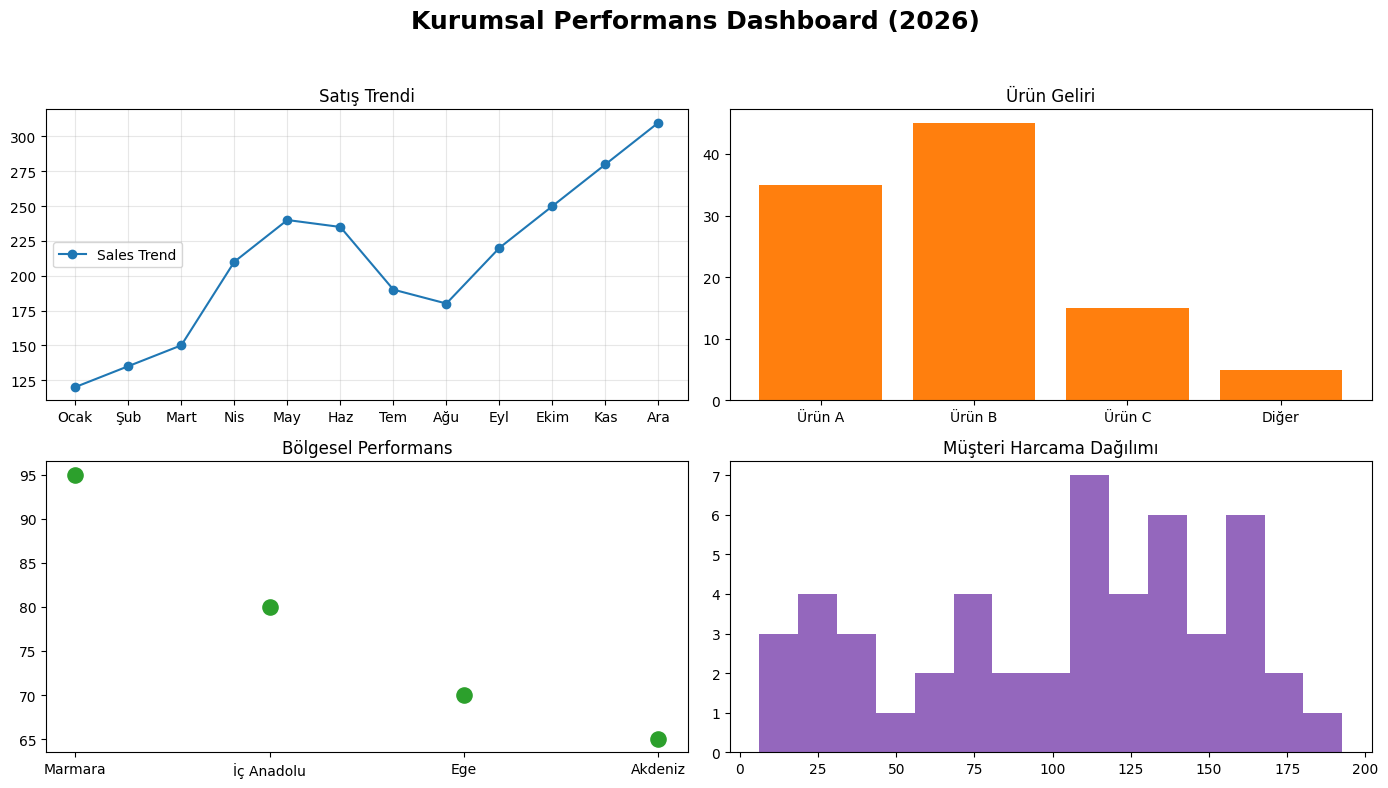

In [35]:
# 6. Farklı Grafik Türleri (Aynı Figürde)
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Kurumsal Performans Dashboard (2026)",
             fontsize=18, fontweight='bold')

# Line Plot
axs[0, 0].plot(months, sales_trend, color=primary_color, marker='o', label='Sales Trend')
axs[0, 0].set_title("Satış Trendi")
axs[0, 0].grid(alpha=0.3)
axs[0, 0].legend(loc=6)

# Bar Plot
axs[0, 1].bar(products, product_shares,
              color=secondary_color)
axs[0, 1].set_title("Ürün Geliri")

# Scatter Plot
axs[1, 0].scatter(regions, region_perf,
                  color=accent_color, s=120)
axs[1, 0].set_title("Bölgesel Performans")

# Histogram
axs[1, 1].hist(spending_amount, bins=15,
               color=neutral_color)
axs[1, 1].set_title("Müşteri Harcama Dağılımı")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Storytelling Akışı

1. Üst Sol: Satış trendi – Şirket büyüyor mu?
2. Üst Sağ: Hangi ürün gelir lideri?
3. Alt Sol: Hangi bölge stratejik avantaj sağlıyor?
4. Alt Sağ: Müşteri harcama davranışı nasıl dağılıyor?

Histogram kullandım çünkü müşteri harcamalarının dağılımını
ve ortalama etrafındaki yayılımı görmek istedim.

Scatter kullandım çünkü bölge performansını sade ve dikkat dağıtmadan karşılaştırmak istedim.

## Executive Summary

• Satışlar Q2 sonunda zirve yapmıştır.
• Product B gelir lideridir.
• Marmara bölgesi stratejik üstünlük sağlamaktadır.
• Müşteri harcamaları normal dağılıma yakın, ortalama 500 TL civarındadır.

### Öneri:
- Product B için kapasite artırımı düşünülebilir.
- Marmara’daki satış modeli diğer bölgelere adapte edilebilir.
- Premium müşteri segmentasyonu yapılabilir.